In [11]:
# Promotional Campaign ROI Analysis
# Dataset: Superstore Sales (Kaggle)
# Author: Marlon Plasencio

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('Orders.csv', encoding='latin-1')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%B')

print("Dataset loaded successfully!")
print(f"Total records: {len(df):,}")
print(f"Date range: {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")
df.head()

Dataset loaded successfully!
Total records: 9,994
Date range: 2014-01-03 to 2017-12-30


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October


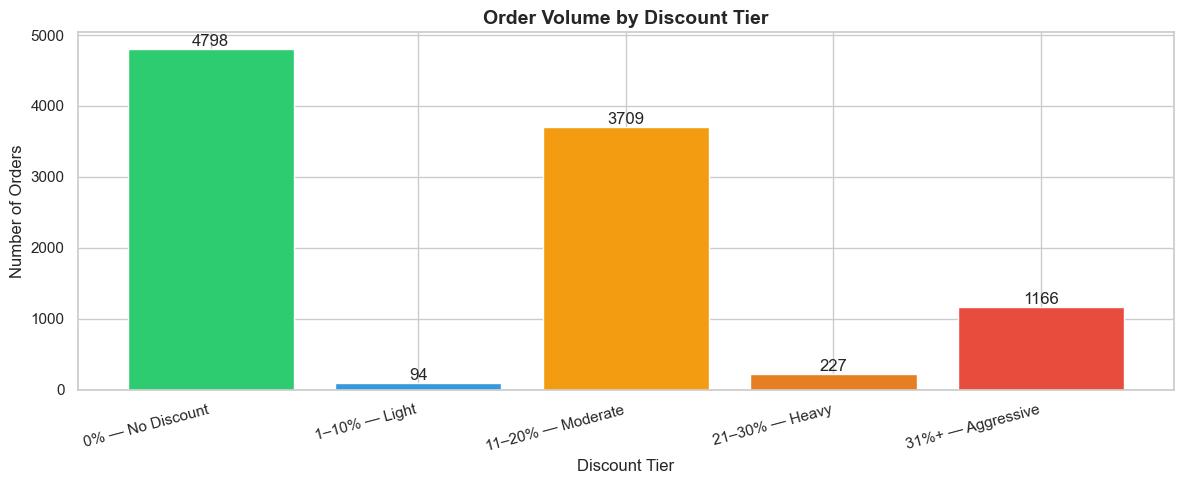

Discount Tier
0% — No Discount     4798
1–10% — Light          94
11–20% — Moderate    3709
21–30% — Heavy        227
31%+ — Aggressive    1166
Name: count, dtype: int64


In [12]:
# ------ Section 2: Understanding the Discount Distribution ----------------------

# Define discount tiers
def discount_tier(d):
    if d == 0:
        return '0% — No Discount'
    elif d <= 0.10:
        return '1–10% — Light'
    elif d <= 0.20:
        return '11–20% — Moderate'
    elif d <= 0.30:
        return '21–30% — Heavy'
    else:
        return '31%+ — Aggressive'

df['Discount Tier'] = df['Discount'].apply(discount_tier)

tier_order = ['0% — No Discount', '1–10% — Light', '11–20% — Moderate',
              '21–30% — Heavy', '31%+ — Aggressive']

tier_counts = df['Discount Tier'].value_counts().reindex(tier_order)

fig, ax = plt.subplots()
bars = ax.bar(tier_counts.index, tier_counts.values, color=['#2ecc71','#3498db','#f39c12','#e67e22','#e74c3c'])
ax.set_title('Order Volume by Discount Tier', fontsize=14, fontweight='bold')
ax.set_xlabel('Discount Tier')
ax.set_ylabel('Number of Orders')
ax.bar_label(bars, fmt='%d')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

print(df['Discount Tier'].value_counts().reindex(tier_order))

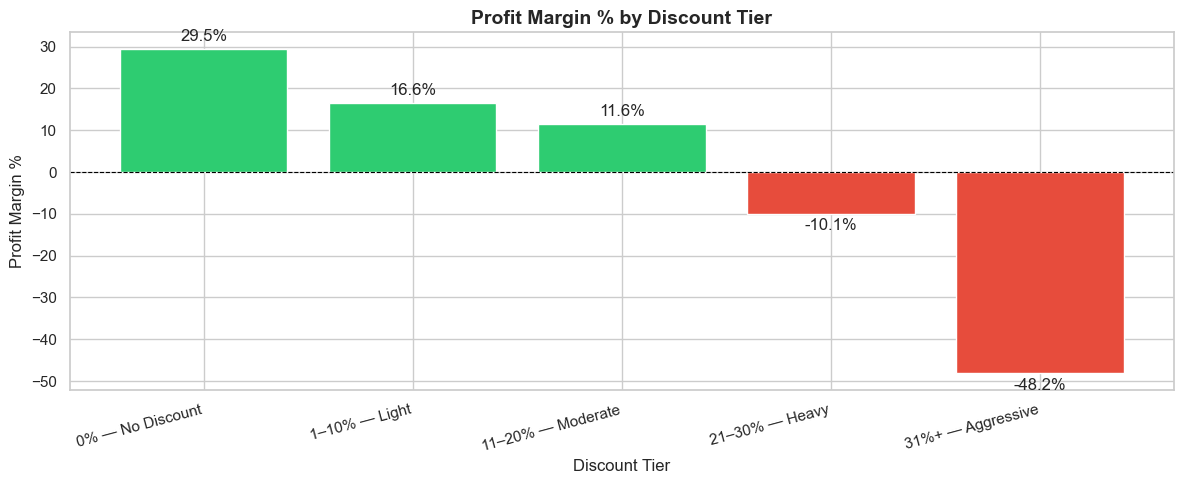

                    Total_Sales  Total_Profit  Profit Margin %  Order_Count
Discount Tier                                                              
0% — No Discount   1.087908e+06   320987.6032            29.51         4798
1–10% — Light      5.436935e+04     9029.1770            16.61           94
11–20% — Moderate  7.921529e+05    91756.2975            11.58         3709
21–30% — Heavy     1.032267e+05   -10369.2774           -10.05          227
31%+ — Aggressive  2.595435e+05  -125006.7786           -48.16         1166


In [13]:
# ----- Section 3: Profit Margin by Discount Tier --------------------------------------

tier_summary = df.groupby('Discount Tier').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Discount=('Discount', 'mean'),
    Order_Count=('Order ID', 'count')
).reindex(tier_order)

tier_summary['Profit Margin %'] = (tier_summary['Total_Profit'] / tier_summary['Total_Sales'] * 100).round(2)
tier_summary['Avg Sales per Order'] = (tier_summary['Total_Sales'] / tier_summary['Order_Count']).round(2)

# Plot profit margin by tier
colors = ['#2ecc71' if x >= 0 else '#e74c3c' for x in tier_summary['Profit Margin %']]

fig, ax = plt.subplots()
bars = ax.bar(tier_summary.index, tier_summary['Profit Margin %'], color=colors)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Profit Margin % by Discount Tier', fontsize=14, fontweight='bold')
ax.set_xlabel('Discount Tier')
ax.set_ylabel('Profit Margin %')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

print(tier_summary[['Total_Sales', 'Total_Profit', 'Profit Margin %', 'Order_Count']].to_string())

C:\Users\marlo\AppData\Local\Temp\ipykernel_16252\1945623705.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(tier_order, rotation=15, ha='right')
C:\Users\marlo\AppData\Local\Temp\ipykernel_16252\1945623705.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(tier_order, rotation=15, ha='right')


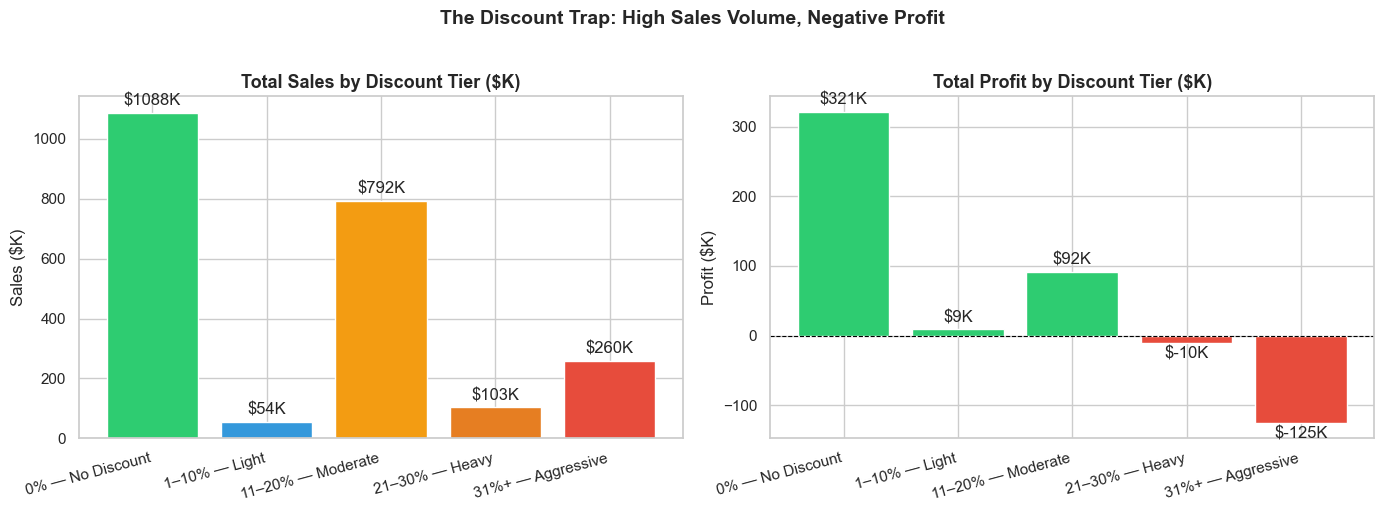

Aggressive discounting generated $259,543 in sales
but lost $125,007 in profit

No-discount orders generated $1,087,908 in sales
and earned $320,988 in profit

Profit destroyed by aggressive discounting: $125,007


In [14]:
# ----- Section 4: Sales Volume vs Profit - The Discount Trap ----------------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Total Sales by tier
colors = ['#2ecc71','#3498db','#f39c12','#e67e22','#e74c3c']
bars1 = ax1.bar(tier_summary.index, tier_summary['Total_Sales'] / 1000, color=colors)
ax1.set_title('Total Sales by Discount Tier ($K)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Sales ($K)')
ax1.bar_label(bars1, fmt='$%.0fK', padding=3)
ax1.set_xticklabels(tier_order, rotation=15, ha='right')

# Right: Total Profit by tier
colors2 = ['#2ecc71' if x >= 0 else '#e74c3c' for x in tier_summary['Total_Profit']]
bars2 = ax2.bar(tier_summary.index, tier_summary['Total_Profit'] / 1000, color=colors2)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('Total Profit by Discount Tier ($K)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Profit ($K)')
ax2.bar_label(bars2, fmt='$%.0fK', padding=3)
ax2.set_xticklabels(tier_order, rotation=15, ha='right')

plt.suptitle('The Discount Trap: High Sales Volume, Negative Profit', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary insight
aggressive = tier_summary.loc['31%+ — Aggressive']
no_disc = tier_summary.loc['0% — No Discount']
print(f"Aggressive discounting generated ${aggressive['Total_Sales']:,.0f} in sales")
print(f"but lost ${abs(aggressive['Total_Profit']):,.0f} in profit")
print(f"")
print(f"No-discount orders generated ${no_disc['Total_Sales']:,.0f} in sales")
print(f"and earned ${no_disc['Total_Profit']:,.0f} in profit")
print(f"")
print(f"Profit destroyed by aggressive discounting: ${abs(aggressive['Total_Profit']):,.0f}")

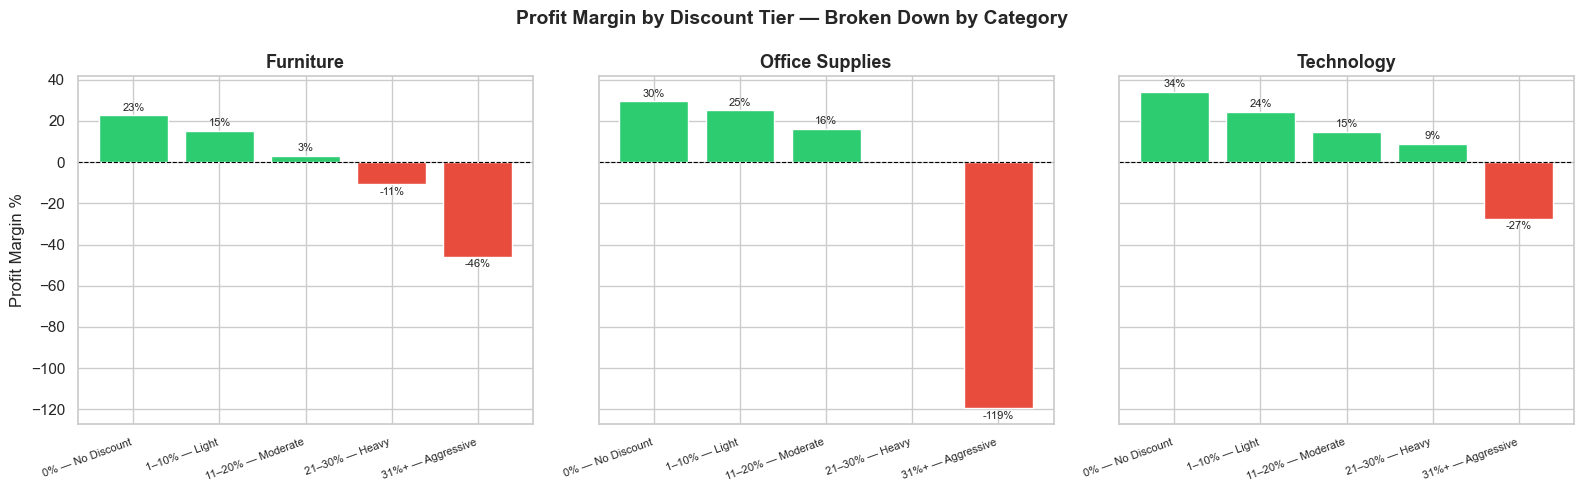



          BUSINESS RECOMMENDATIONS                              


1. CAP DISCOUNTS AT 20%
   Discounts above 20% consistently produce negative margins across
   all categories. A company-wide cap of 20% would protect profitability
   while still offering competitive promotions.

2. ELIMINATE AGGRESSIVE DISCOUNTING IN FURNITURE
   Furniture already has thin margins. Aggressive discounting in this
   category is especially damaging — discount strategy should focus
   on Technology and Office Supplies where margin is more resilient.

3. PROTECT NO-DISCOUNT SALES CHANNELS
   Nearly 48% of orders carry no discount and generate a 29.5% margin.
   Loyalty programs, bundling, and value-add strategies should be
   prioritized to grow this segment instead of relying on discounts
   to drive volume.

4. AUDIT THE 1,166 AGGRESSIVE DISCOUNT ORDERS
   These orders destroyed $125,007 in profit. A review should identify
   whether these were authorized promotions, sales rep discounts, or
   clearan

In [15]:
# -------- Section 5: Category Breakdown & Business Recommendations ---------------------------

cat_tier = df.groupby(['Category', 'Discount Tier']).agg(
    Total_Profit=('Profit', 'sum'),
    Total_Sales=('Sales', 'sum'),
    Order_Count=('Order ID', 'count')
).reset_index()

cat_tier['Profit Margin %'] = (cat_tier['Total_Profit'] / cat_tier['Total_Sales'] * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
categories = ['Furniture', 'Office Supplies', 'Technology']

for ax, cat in zip(axes, categories):
    data = cat_tier[cat_tier['Category'] == cat].set_index('Discount Tier').reindex(tier_order)
    colors = ['#2ecc71' if x >= 0 else '#e74c3c' for x in data['Profit Margin %']]
    bars = ax.bar(data.index, data['Profit Margin %'], color=colors)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(cat, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.bar_label(bars, fmt='%.0f%%', padding=2, fontsize=8)
    ax.set_xticks(range(len(tier_order)))
    ax.set_xticklabels(tier_order, rotation=20, ha='right', fontsize=8)

axes[0].set_ylabel('Profit Margin %')
plt.suptitle('Profit Margin by Discount Tier — Broken Down by Category',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --------------- Business Recommendations ---------------------
print("""

          BUSINESS RECOMMENDATIONS                              


1. CAP DISCOUNTS AT 20%
   Discounts above 20% consistently produce negative margins across
   all categories. A company-wide cap of 20% would protect profitability
   while still offering competitive promotions.

2. ELIMINATE AGGRESSIVE DISCOUNTING IN FURNITURE
   Furniture already has thin margins. Aggressive discounting in this
   category is especially damaging — discount strategy should focus
   on Technology and Office Supplies where margin is more resilient.

3. PROTECT NO-DISCOUNT SALES CHANNELS
   Nearly 48% of orders carry no discount and generate a 29.5% margin.
   Loyalty programs, bundling, and value-add strategies should be
   prioritized to grow this segment instead of relying on discounts
   to drive volume.

4. AUDIT THE 1,166 AGGRESSIVE DISCOUNT ORDERS
   These orders destroyed $125,007 in profit. A review should identify
   whether these were authorized promotions, sales rep discounts, or
   clearance items and whether the volume gained justified the loss.
""")